# **Data Loading**


In [1]:
import pandas as pd

train = pd.read_csv('/content/train_videos.csv')
test = pd.read_csv('/content/test_videos.csv')
engagement = pd.read_csv('/content/engagement_daily.csv')
creators = pd.read_csv('/content/creators_daily.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')

print("Train:", train.shape)
print("Test:", test.shape)
print("Engagement:", engagement.shape)
print("Creators:", creators.shape)
print("Sample submission:", sample_submission.shape)

Train: (12000, 27)
Test: (3001, 26)
Engagement: (79489, 10)
Creators: (252166, 7)
Sample submission: (3001, 2)


# **Data Inspection**

In [2]:
print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nTEST COLUMNS")
print(test.columns.tolist())

print("\nENGAGEMENT COLUMNS")
print(engagement.columns.tolist())

print("\nCREATORS COLUMNS")
print(creators.columns.tolist())

TRAIN COLUMNS
['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear', 'target_day30_views']

TEST COLUMNS
['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']

ENGAGEMENT COLUMNS
['video_id', 'date', 'days_since_post', 'play_count', 'like_count', 'comment_count', 'share_count', 'collect_count', 'download_count', 'whatsapp_share_count']

CREATORS COLUMNS
['author_id', 'date', 'follower_count', 'followin

# **Missing Values and Duplicates**

In [3]:
print("Missing values in TRAIN:")
print(train.isnull().sum())

print("\nMissing values in TEST:")
print(test.isnull().sum())

print("\nMissing values in ENGAGEMENT:")
print(engagement.isnull().sum())

print("\nMissing values in CREATORS:")
print(creators.isnull().sum())

Missing values in TRAIN:
video_id                  0
author_id                 0
create_time               0
create_date               0
duration                  0
ratio                     0
desc_language             0
is_english                0
created_by_ai             0
is_ads                    0
music_selected_from     121
music_author             21
music_owner_id         2972
music_id                  1
word_count             4047
emoji_count            4047
question_count         4047
hashtag_count          4047
speaking_rate          4047
topic                     0
anger                    42
joy                      42
surprise                 42
sadness                  42
disgust                  42
fear                     42
target_day30_views        0
dtype: int64

Missing values in TEST:
video_id                  0
author_id                 0
create_time               0
create_date               0
duration                  0
ratio                     0
desc_language

In [4]:
print("Duplicate rows:")
print("Train:", train.duplicated().sum())
print("Test:", test.duplicated().sum())
print("Engagement:", engagement.duplicated().sum())
print("Creators:", creators.duplicated().sum())

Duplicate rows:
Train: 0
Test: 0
Engagement: 0
Creators: 0


# **Data Understanding**

In [5]:
print("Engagement days:")
print(engagement['days_since_post'].value_counts().sort_index())

print("\nUnique videos in engagement:")
print(engagement['video_id'].nunique())

print("\nUnique authors in creators:")
print(creators['author_id'].nunique())

print("\nCreator records per author:")
print(creators.groupby('author_id').size().describe())

Engagement days:
days_since_post
0     5638
1    14750
2    14726
3    14768
4    14856
5    14751
Name: count, dtype: int64

Unique videos in engagement:
15000

Unique authors in creators:
1671

Creator records per author:
count    1671.000000
mean      150.907241
std        17.196167
min        48.000000
25%       151.000000
50%       158.000000
75%       160.000000
max       161.000000
dtype: float64


# **EDA**

In [6]:
# Most viewed video
most_viewed = train.loc[train['target_day30_views'].idxmax()]

# Least viewed video
least_viewed = train.loc[train['target_day30_views'].idxmin()]

print("Most Viewed Video:")
print(most_viewed[['video_id', 'author_id', 'target_day30_views']])

print("\nLeast Viewed Video:")
print(least_viewed[['video_id', 'author_id', 'target_day30_views']])

Most Viewed Video:
video_id              7433609207527574826
author_id              136013345668669441
target_day30_views               16310546
Name: 11115, dtype: object

Least Viewed Video:
video_id              7413218325121076510
author_id             7115852322888746030
target_day30_views                      0
Name: 2527, dtype: object


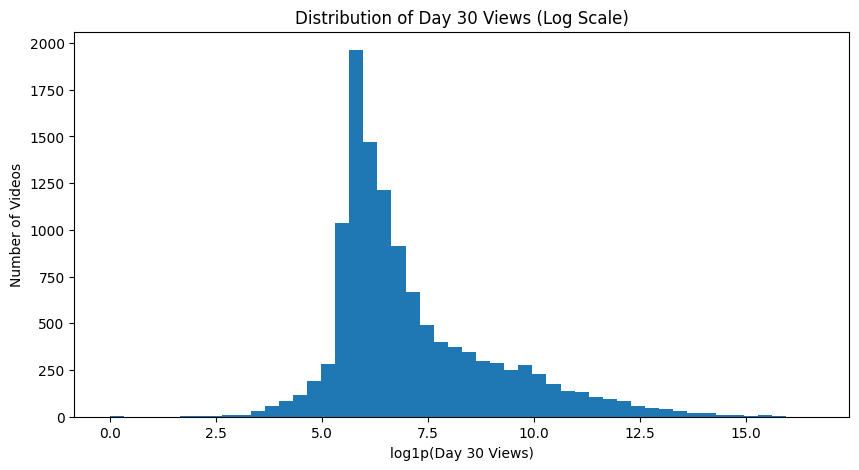

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(train['target_day30_views']), bins=50)
plt.xlabel('log1p(Day 30 Views)')
plt.ylabel('Number of Videos')
plt.title('Distribution of Day 30 Views (Log Scale)')
plt.show()

In [8]:
# Convert create_time to datetime
train['create_time_dt'] = pd.to_datetime(train['create_time'])

# Extract hour
train['hour'] = train['create_time_dt'].dt.hour

# Morning vs Evening
train['time_period'] = train['hour'].apply(
    lambda x: 'Morning' if 5 <= x < 12
    else 'Afternoon' if 12 <= x < 17
    else 'Evening' if 17 <= x < 22
    else 'Night'
)

# Convert date to datetime
train['create_date_dt'] = pd.to_datetime(train['create_date'])

# Get day of week
train['day_of_week'] = train['create_date_dt'].dt.day_name()

# Weekend vs Weekday
train['day_type'] = train['create_date_dt'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [10]:
train.groupby('day_type')['target_day30_views'].agg(
    ['count', 'mean', 'median', 'max']
)

,count,mean,median,max
day_type,,,,
Weekday,9026,30379.737093,675.0,16310546
Weekend,2974,25734.953598,646.0,4999018


In [11]:
train.groupby('day_of_week')['target_day30_views'].agg(
    ['count', 'mean', 'median', 'max']
).sort_values('median', ascending=False)

,count,mean,median,max
day_of_week,,,,
Wednesday,1918,28325.227320,749.0,7380943
Saturday,1397,29689.046528,693.0,4999018
Monday,1719,39121.756835,676.0,16310546
Thursday,1837,31017.303212,661.0,7222986
Friday,1556,26798.596401,650.0,7392530
Tuesday,1996,27030.069639,642.0,7283358
Sunday,1577,22232.183893,623.0,4707681


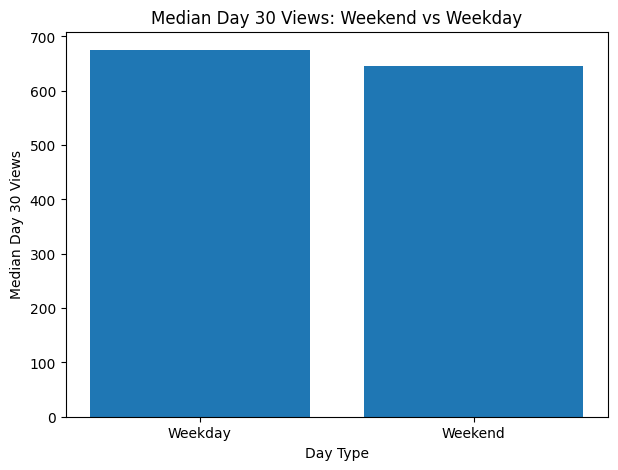

In [12]:
day_stats = train.groupby('day_type')['target_day30_views'].agg(
    count='count',
    median='median'
).reset_index()

plt.figure(figsize=(7, 5))
plt.bar(day_stats['day_type'], day_stats['median'])
plt.xlabel('Day Type')
plt.ylabel('Median Day 30 Views')
plt.title('Median Day 30 Views: Weekend vs Weekday')
plt.show()

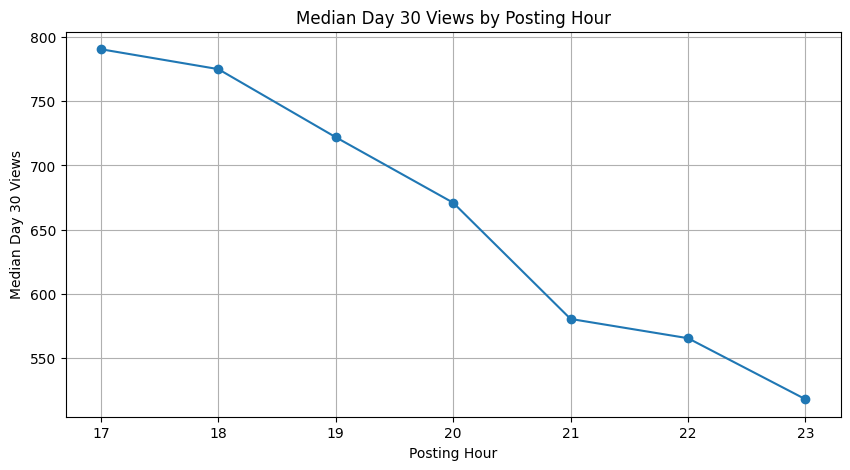

In [14]:
hour_stats = train.groupby('hour')['target_day30_views'].agg(
    count='count',
    median='median'
).reset_index()

# Keep hours with at least 100 videos
hour_stats = hour_stats[hour_stats['count'] >= 100]

plt.figure(figsize=(10, 5))
plt.plot(hour_stats['hour'], hour_stats['median'], marker='o')
plt.xlabel('Posting Hour')
plt.ylabel('Median Day 30 Views')
plt.title('Median Day 30 Views by Posting Hour')
plt.xticks(range(17, 24))
plt.grid(True)
plt.show()

In [15]:
### Early Engagement vs Day 30 Views

day5 = engagement[engagement['days_since_post'] == 5][
    ['video_id', 'play_count']
].copy()

day5 = day5.rename(columns={'play_count': 'day5_views'})

train_day5 = train.merge(day5, on='video_id', how='inner')

print("Videos with Day 5 data:", len(train_day5))

Videos with Day 5 data: 11790


In [16]:
train_day5[['day5_views', 'target_day30_views']].corr()

,day5_views,target_day30_views
day5_views,1.000000,0.970695
target_day30_views,0.970695,1.000000


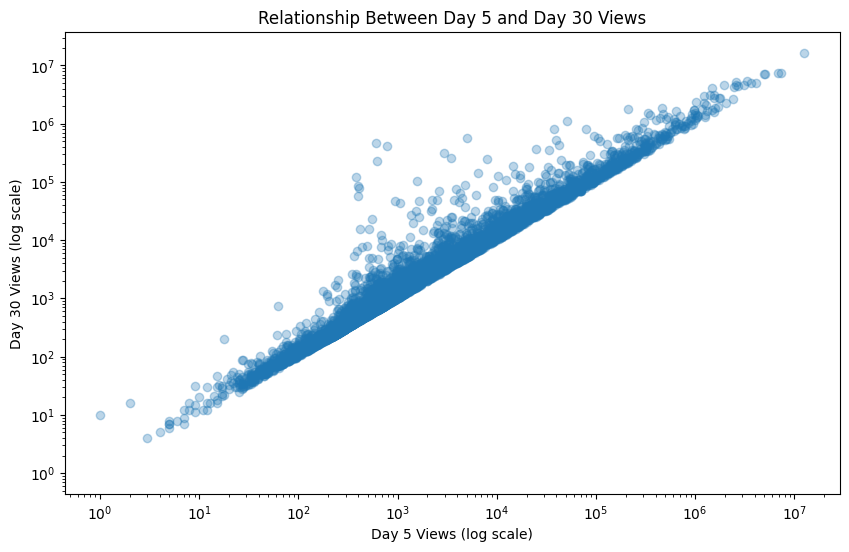

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_day5['day5_views'],
    train_day5['target_day30_views'],
    alpha=0.3
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Day 5 Views (log scale)')
plt.ylabel('Day 30 Views (log scale)')
plt.title('Relationship Between Day 5 and Day 30 Views')

plt.show()

In [18]:
# Correlation between views at each day and Day 30 views

for day in range(6):
    day_data = engagement[engagement['days_since_post'] == day][
        ['video_id', 'play_count']
    ].rename(columns={'play_count': f'day{day}_views'})

    temp = train.merge(day_data, on='video_id', how='inner')

    correlation = temp[f'day{day}_views'].corr(
        temp['target_day30_views']
    )

    print(f'Day {day}: correlation = {correlation:.4f}')

Day 0: correlation = 0.5699
Day 1: correlation = 0.7649
Day 2: correlation = 0.9070
Day 3: correlation = 0.9451
Day 4: correlation = 0.9620
Day 5: correlation = 0.9707


In [19]:
### Engagement Metrics vs Day 30 Views

# Use Day 5 engagement data
day5_engagement = engagement[
    engagement['days_since_post'] == 5
].copy()

engagement_cols = [
    'play_count',
    'like_count',
    'comment_count',
    'share_count',
    'collect_count',
    'download_count',
    'whatsapp_share_count'
]

train_engagement = train.merge(
    day5_engagement[['video_id'] + engagement_cols],
    on='video_id',
    how='inner'
)

correlations = train_engagement[
    engagement_cols + ['target_day30_views']
].corr()['target_day30_views'].drop('target_day30_views')

correlations.sort_values(ascending=False)

,target_day30_views
play_count,0.970695
like_count,0.880009
collect_count,0.678167
share_count,0.639336
whatsapp_share_count,0.587106
comment_count,0.507607
download_count,0.401917


In [20]:
### Engagement Rates vs Day 30 Views

train_engagement['like_rate'] = (
    train_engagement['like_count'] /
    train_engagement['play_count'].replace(0, np.nan)
)

train_engagement['comment_rate'] = (
    train_engagement['comment_count'] /
    train_engagement['play_count'].replace(0, np.nan)
)

train_engagement['share_rate'] = (
    train_engagement['share_count'] /
    train_engagement['play_count'].replace(0, np.nan)
)

train_engagement['collect_rate'] = (
    train_engagement['collect_count'] /
    train_engagement['play_count'].replace(0, np.nan)
)

rate_cols = [
    'like_rate',
    'comment_rate',
    'share_rate',
    'collect_rate'
]

train_engagement[rate_cols + ['target_day30_views']].corr()[
    'target_day30_views'
].drop('target_day30_views').sort_values(ascending=False)

,target_day30_views
share_rate,0.061684
collect_rate,0.035725
like_rate,0.027349
comment_rate,-0.041137


In [21]:
### Creator Stats vs Day 30 Views

# Convert dates
train['create_date_dt'] = pd.to_datetime(train['create_date'])
creators['date_dt'] = pd.to_datetime(creators['date'])

# Creator features
creator_cols = [
    'author_id',
    'date_dt',
    'follower_count',
    'following_count',
    'total_favorited',
    'video_count'
]

# Match creator statistics with the video on the same date
train_creator = train.merge(
    creators[creator_cols],
    left_on=['author_id', 'create_date_dt'],
    right_on=['author_id', 'date_dt'],
    how='left'
)

# Correlation with Day 30 views
creator_features = [
    'follower_count',
    'following_count',
    'total_favorited',
    'video_count'
]

creator_correlations = (
    train_creator[
        creator_features + ['target_day30_views']
    ]
    .corr()['target_day30_views']
    .drop('target_day30_views')
    .sort_values(ascending=False)
)

print("Videos with creator data:",
      train_creator['follower_count'].notna().sum())

print("\nCorrelation with Day 30 Views:")
print(creator_correlations)

Videos with creator data: 12000

Correlation with Day 30 Views:
follower_count     0.262636
total_favorited    0.254296
video_count        0.006482
following_count   -0.045848
Name: target_day30_views, dtype: float64


# **Coverage Check**

In [22]:
train_test_ids = pd.concat([
    train[['video_id']],
    test[['video_id']]
]).drop_duplicates()

engagement_ids = set(engagement['video_id'])

print("Total train + test videos:", len(train_test_ids))
print("Videos with engagement data:",
      train_test_ids['video_id'].isin(engagement_ids).sum())
print("Videos without engagement data:",
      (~train_test_ids['video_id'].isin(engagement_ids)).sum())
days_per_video = (
    engagement.groupby('video_id')['days_since_post']
    .nunique()
)

print(days_per_video.value_counts().sort_index())

Total train + test videos: 15001
Videos with engagement data: 15000
Videos without engagement data: 1
days_since_post
1       1
2       2
3      14
4     643
5    9170
6    5170
Name: count, dtype: int64


# **Engagement Day Coverage**

In [23]:
day_coverage = (
    engagement
    .groupby('video_id')['days_since_post']
    .apply(lambda x: sorted(x.unique()))
)

print(day_coverage.value_counts().head(20))
incomplete_videos = day_coverage[day_coverage.apply(len) < 6]

print(incomplete_videos.head(20))

days_since_post
[1, 2, 3, 4, 5]       8709
[0, 1, 2, 3, 4, 5]    5170
[1, 3, 4, 5]           150
[1, 2, 4, 5]           138
[2, 3, 4, 5]           137
[1, 2, 3, 4]           131
[0, 1, 3, 4, 5]        110
[0, 1, 2, 3, 4]        110
[0, 2, 3, 4, 5]         98
[0, 1, 2, 4, 5]         86
[1, 2, 3, 5]            81
[0, 1, 2, 3, 5]         57
[3, 4, 5]                5
[1, 2, 3]                3
[4, 5]                   2
[0, 3, 4, 5]             2
[0, 1, 4, 5]             2
[2, 3, 4]                2
[1, 4, 5]                2
[2, 4, 5]                1
Name: count, dtype: int64
video_id
7384201316735683883    [1, 2, 3, 4, 5]
7384206382179831070    [1, 2, 3, 4, 5]
7384207738194152735    [1, 2, 3, 4, 5]
7384207980855676190    [1, 2, 3, 4, 5]
7384208845876301086    [1, 2, 3, 4, 5]
7384208970774383918    [1, 2, 3, 4, 5]
7384210748752366891    [1, 2, 3, 4, 5]
7384213702624562463    [1, 2, 3, 4, 5]
7384214627338636590    [1, 2, 3, 4, 5]
7384215117958892843    [1, 2, 3, 4, 5]
7384215611330546986

In [10]:
sample_video = engagement['video_id'].value_counts().index[0]

print(
    engagement[engagement['video_id'] == sample_video]
    .sort_values('days_since_post')
    .to_string(index=False)
)

           video_id       date  days_since_post  play_count  like_count  comment_count  share_count  collect_count  download_count  whatsapp_share_count
7435476776551337247 2024-11-09                0          11           1              0            0              0               0                     0
7435476776551337247 2024-11-10                1          83          18              3            1              2               0                     0
7435476776551337247 2024-11-11                2         106          22              4            1              2               0                     0
7435476776551337247 2024-11-12                3         108          22              4            1              2               0                     0
7435476776551337247 2024-11-13                4         115          23              4            1              2               0                     0
7435476776551337247 2024-11-14                5         117          23           

# **Data Cleaning**

In [24]:
# Check Data Types

print("Train Data Types:")
print(train.dtypes)

print("\nTest Data Types:")
print(test.dtypes)

print("\nEngagement Data Types:")
print(engagement.dtypes)

print("\nCreators Data Types:")
print(creators.dtypes)

Train Data Types:
video_id                        int64
author_id                       int64
create_time                    object
create_date                    object
duration                      float64
ratio                          object
desc_language                  object
is_english                      int64
created_by_ai                 float64
is_ads                          int64
music_selected_from            object
music_author                   object
music_owner_id                float64
music_id                      float64
word_count                    float64
emoji_count                   float64
question_count                float64
hashtag_count                 float64
speaking_rate                 float64
topic                          object
anger                         float64
joy                           float64
surprise                      float64
sadness                       float64
disgust                       float64
fear                          fl

In [25]:
# Check Numerical Values

print("Train Numerical Summary:")
display(train.describe().T)

print("\nTest Numerical Summary:")
display(test.describe().T)

Train Numerical Summary:


,count,mean,min,25%,50%,75%,max,std
video_id,12000.0,7407546889540649984.0,7384086821132717056.0,7394627651903888384.0,7407235856536243200.0,7419845870098631680.0,7435523911346965504.0,14553910281993106.0
author_id,12000.0,5731385843138812928.0,37986.0,6759666429061301248.0,6808736715970429952.0,6880365187033170944.0,7296519099122385920.0,2530010445313954304.0
duration,12000.0,36.996859,1.95,11.748,20.4505,57.979,191.403,36.126852
is_english,12000.0,0.641333,0.0,0.0,1.0,1.0,1.0,0.479629
created_by_ai,12000.0,0.00375,0.0,0.0,0.0,0.0,1.0,0.061125
is_ads,12000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
music_owner_id,9028.0,6315515023948520448.0,37986.0,6765324623233106944.0,6836026725744264192.0,7025016836120036352.0,7430532004372759552.0,1961030065918885120.0
music_id,11999.0,7221202562331512832.0,5498.0,7220988286234799104.0,7384815268697410560.0,7405427848034397184.0,7435523825892166656.0,672818560332431744.0
word_count,7953.0,62.177795,0.0,4.0,16.0,64.0,871.0,102.105801
emoji_count,7953.0,1.219666,0.0,0.0,0.0,2.0,29.0,2.213721



Test Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
video_id,3001.0,7.408047e+18,1.452780e+16,7.384178e+18,7.395371e+18,7.407612e+18,7.420563e+18,7.435505e+18
author_id,3001.0,5.803974e+18,2.466602e+18,3.798600e+04,6.760151e+18,6.808939e+18,6.881072e+18,7.282370e+18
duration,3001.0,3.546635e+01,3.519626e+01,1.834000e+00,1.163400e+01,1.887700e+01,5.510100e+01,1.903580e+02
is_english,3001.0,6.404532e-01,4.799476e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
created_by_ai,3001.0,4.665112e-03,6.815347e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_ads,3001.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
music_owner_id,2282.0,6.368532e+18,1.884957e+18,3.798600e+04,6.767877e+18,6.846036e+18,7.027121e+18,7.420649e+18
music_id,3000.0,7.220309e+18,6.908215e+17,2.318445e+07,7.231160e+18,7.384948e+18,7.405414e+18,7.435467e+18
word_count,1952.0,5.891035e+01,1.020209e+02,0.000000e+00,4.000000e+00,1.600000e+01,5.500000e+01,7.530000e+02
emoji_count,1952.0,1.220799e+00,2.316990e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.500000e+01


In [26]:
# Check Categorical Values

categorical_cols = train.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print("Unique values:", train[col].nunique())
    print(train[col].value_counts(dropna=False).head(10))


create_time:
Unique values: 11975
create_time
2024-07-04 17:15:28    2
2024-07-02 17:28:57    2
2024-08-05 21:52:17    2
2024-09-12 20:02:53    2
2024-06-30 17:02:45    2
2024-08-16 20:16:30    2
2024-08-13 17:39:55    2
2024-07-28 19:42:08    2
2024-07-31 23:52:07    2
2024-10-22 18:58:44    2
Name: count, dtype: int64

create_date:
Unique values: 127
create_date
2024-07-15    139
2024-07-17    137
2024-06-26    130
2024-09-25    129
2024-07-25    126
2024-06-25    124
2024-07-30    124
2024-07-01    123
2024-10-17    122
2024-07-16    121
Name: count, dtype: int64

ratio:
Unique values: 5
ratio
540p     11131
720p       821
480p        34
360p        13
1080p        1
Name: count, dtype: int64

desc_language:
Unique values: 2
desc_language
en    7696
un    4304
Name: count, dtype: int64

music_selected_from:
Unique values: 39
music_selected_from
original                          4574
single_song                       2541
edit_page_recommend               1328
edit_page_search      

In [27]:
# Check Missing Values

print("Train Missing Values:")
print(train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False))

print("\nTest Missing Values:")
print(test.isnull().sum()[test.isnull().sum() > 0].sort_values(ascending=False))

Train Missing Values:
question_count         4047
emoji_count            4047
word_count             4047
speaking_rate          4047
hashtag_count          4047
music_owner_id         2972
music_selected_from     121
surprise                 42
sadness                  42
anger                    42
joy                      42
disgust                  42
fear                     42
music_author             21
music_id                  1
dtype: int64

Test Missing Values:
question_count         1049
emoji_count            1049
word_count             1049
speaking_rate          1049
hashtag_count          1049
music_owner_id          719
music_selected_from      31
surprise                 15
sadness                  15
anger                    15
joy                      15
disgust                  15
fear                     15
music_author              7
music_id                  1
dtype: int64


In [28]:
# Convert ID Columns to String

id_cols = ['video_id', 'author_id', 'music_owner_id', 'music_id']

for col in id_cols:
    train[col] = train[col].astype('string')
    test[col] = test[col].astype('string')

print(train[id_cols].dtypes)

video_id          string[python]
author_id         string[python]
music_owner_id    string[python]
music_id          string[python]
dtype: object


In [29]:
# Convert Date Columns to Datetime

train['create_time'] = pd.to_datetime(train['create_time'])
train['create_date'] = pd.to_datetime(train['create_date'])

test['create_time'] = pd.to_datetime(test['create_time'])
test['create_date'] = pd.to_datetime(test['create_date'])

engagement['date'] = pd.to_datetime(engagement['date'])
creators['date'] = pd.to_datetime(creators['date'])

print("Train:")
print(train[['create_time', 'create_date']].dtypes)

print("\nTest:")
print(test[['create_time', 'create_date']].dtypes)

print("\nEngagement:")
print(engagement['date'].dtype)

print("\nCreators:")
print(creators['date'].dtype)

Train:
create_time    datetime64[ns]
create_date    datetime64[ns]
dtype: object

Test:
create_time    datetime64[ns]
create_date    datetime64[ns]
dtype: object

Engagement:
datetime64[ns]

Creators:
datetime64[ns]


In [30]:
# Check for Invalid Values

print("Duration <= 0:", (train['duration'] <= 0).sum())
print("Word count < 0:", (train['word_count'] < 0).sum())
print("Emoji count < 0:", (train['emoji_count'] < 0).sum())
print("Question count < 0:", (train['question_count'] < 0).sum())
print("Hashtag count < 0:", (train['hashtag_count'] < 0).sum())
print("Speaking rate < 0:", (train['speaking_rate'] < 0).sum())

emotion_cols = ['anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']

for col in emotion_cols:
    print(f"{col} outside [0, 1]:",
          ((train[col] < 0) | (train[col] > 1)).sum())

Duration <= 0: 0
Word count < 0: 0
Emoji count < 0: 0
Question count < 0: 0
Hashtag count < 0: 0
Speaking rate < 0: 0
anger outside [0, 1]: 0
joy outside [0, 1]: 0
surprise outside [0, 1]: 0
sadness outside [0, 1]: 0
disgust outside [0, 1]: 0
fear outside [0, 1]: 0


# Feature Engineering

In [31]:
# 6.1 Early Engagement Features

engagement_features = engagement.copy()

# Sort by video and day
engagement_features = engagement_features.sort_values(
    ['video_id', 'days_since_post']
)

# Keep the latest available engagement record for each video
latest_engagement = (
    engagement_features
    .groupby('video_id')
    .tail(1)
)

latest_engagement = latest_engagement[
    [
        'video_id',
        'days_since_post',
        'play_count',
        'like_count',
        'comment_count',
        'share_count',
        'collect_count',
        'download_count',
        'whatsapp_share_count'
    ]
].copy()

# Rename columns
latest_engagement = latest_engagement.rename(columns={
    'days_since_post': 'latest_day',
    'play_count': 'latest_views',
    'like_count': 'latest_likes',
    'comment_count': 'latest_comments',
    'share_count': 'latest_shares',
    'collect_count': 'latest_collects',
    'download_count': 'latest_downloads',
    'whatsapp_share_count': 'latest_whatsapp_shares'
})

print("Latest engagement shape:", latest_engagement.shape)
display(latest_engagement.head())

Latest engagement shape: (15000, 9)


,video_id,latest_day,latest_views,latest_likes,latest_comments,latest_shares,latest_collects,latest_downloads,latest_whatsapp_shares
5,7384086821132717358,5,478085,47109,143,5936,10987,368,34
11,7384175589206265118,5,557,19,0,0,2,0,0
17,7384177529092951338,5,11743,1506,77,54,58,1,0
23,7384193780057984287,5,423,42,3,0,6,0,0
29,7384193851700956447,5,2697,45,0,11,6,1,1


In [32]:
# Check Latest Available Day

print(
    latest_engagement['latest_day']
    .value_counts()
    .sort_index()
)

latest_day
0        1
3        4
4      244
5    14751
Name: count, dtype: int64


In [33]:
# Day 5 Engagement Features

day5_features = engagement[
    engagement['days_since_post'] == 5
][
    [
        'video_id',
        'play_count',
        'like_count',
        'comment_count',
        'share_count',
        'collect_count',
        'download_count',
        'whatsapp_share_count'
    ]
].copy()

day5_features = day5_features.rename(columns={
    'play_count': 'day5_views',
    'like_count': 'day5_likes',
    'comment_count': 'day5_comments',
    'share_count': 'day5_shares',
    'collect_count': 'day5_collects',
    'download_count': 'day5_downloads',
    'whatsapp_share_count': 'day5_whatsapp_shares'
})

print("Day 5 features shape:", day5_features.shape)
display(day5_features.head())

Day 5 features shape: (14751, 8)


,video_id,day5_views,day5_likes,day5_comments,day5_shares,day5_collects,day5_downloads,day5_whatsapp_shares
5,7384086821132717358,478085,47109,143,5936,10987,368,34
11,7384175589206265118,557,19,0,0,2,0,0
17,7384177529092951338,11743,1506,77,54,58,1,0
23,7384193780057984287,423,42,3,0,6,0,0
29,7384193851700956447,2697,45,0,11,6,1,1


In [34]:
# Day 5 Engagement Rates

day5_features['day5_like_rate'] = (
    day5_features['day5_likes'] /
    day5_features['day5_views'].replace(0, np.nan)
)

day5_features['day5_comment_rate'] = (
    day5_features['day5_comments'] /
    day5_features['day5_views'].replace(0, np.nan)
)

day5_features['day5_share_rate'] = (
    day5_features['day5_shares'] /
    day5_features['day5_views'].replace(0, np.nan)
)

day5_features['day5_collect_rate'] = (
    day5_features['day5_collects'] /
    day5_features['day5_views'].replace(0, np.nan)
)

day5_features['day5_download_rate'] = (
    day5_features['day5_downloads'] /
    day5_features['day5_views'].replace(0, np.nan)
)

day5_features['day5_whatsapp_rate'] = (
    day5_features['day5_whatsapp_shares'] /
    day5_features['day5_views'].replace(0, np.nan)
)

display(day5_features.head())

,video_id,day5_views,day5_likes,day5_comments,day5_shares,day5_collects,day5_downloads,day5_whatsapp_shares,day5_like_rate,day5_comment_rate,day5_share_rate,day5_collect_rate,day5_download_rate,day5_whatsapp_rate
5,7384086821132717358,478085,47109,143,5936,10987,368,34,0.098537,0.000299,0.012416,0.022981,0.000770,0.000071
11,7384175589206265118,557,19,0,0,2,0,0,0.034111,0.000000,0.000000,0.003591,0.000000,0.000000
17,7384177529092951338,11743,1506,77,54,58,1,0,0.128247,0.006557,0.004598,0.004939,0.000085,0.000000
23,7384193780057984287,423,42,3,0,6,0,0,0.099291,0.007092,0.000000,0.014184,0.000000,0.000000
29,7384193851700956447,2697,45,0,11,6,1,1,0.016685,0.000000,0.004079,0.002225,0.000371,0.000371


In [35]:
# Early Growth Features

day1_views = (
    engagement[engagement['days_since_post'] == 1]
    [['video_id', 'play_count']]
    .rename(columns={'play_count': 'day1_views'})
)

day5_features = day5_features.merge(
    day1_views,
    on='video_id',
    how='left'
)

day5_features['views_growth_day1_to_day5'] = (
    day5_features['day5_views'] -
    day5_features['day1_views']
)

day5_features['views_growth_ratio_day1_to_day5'] = (
    day5_features['day5_views'] /
    day5_features['day1_views'].replace(0, np.nan)
)

display(
    day5_features[
        [
            'video_id',
            'day1_views',
            'day5_views',
            'views_growth_day1_to_day5',
            'views_growth_ratio_day1_to_day5'
        ]
    ].head()
)

,video_id,day1_views,day5_views,views_growth_day1_to_day5,views_growth_ratio_day1_to_day5
0,7384086821132717358,330084.0,478085,148001.0,1.448374
1,7384175589206265118,323.0,557,234.0,1.724458
2,7384177529092951338,11045.0,11743,698.0,1.063196
3,7384193780057984287,356.0,423,67.0,1.188202
4,7384193851700956447,1414.0,2697,1283.0,1.907355


In [36]:
# Average Daily Growth

day5_features['avg_daily_view_growth'] = (
    day5_features['views_growth_day1_to_day5'] / 4
)

display(
    day5_features[
        [
            'video_id',
            'day1_views',
            'day5_views',
            'views_growth_day1_to_day5',
            'avg_daily_view_growth'
        ]
    ].head()
)

,video_id,day1_views,day5_views,views_growth_day1_to_day5,avg_daily_view_growth
0,7384086821132717358,330084.0,478085,148001.0,37000.25
1,7384175589206265118,323.0,557,234.0,58.50
2,7384177529092951338,11045.0,11743,698.0,174.50
3,7384193780057984287,356.0,423,67.0,16.75
4,7384193851700956447,1414.0,2697,1283.0,320.75


In [37]:
# Daily View Growth Features

views_pivot = (
    engagement
    .pivot_table(
        index='video_id',
        columns='days_since_post',
        values='play_count',
        aggfunc='last'
    )
    .rename(columns=lambda x: f'views_day{x}')
)

views_pivot['growth_day1_to_day2'] = (
    views_pivot['views_day2'] - views_pivot['views_day1']
)

views_pivot['growth_day2_to_day3'] = (
    views_pivot['views_day3'] - views_pivot['views_day2']
)

views_pivot['growth_day3_to_day4'] = (
    views_pivot['views_day4'] - views_pivot['views_day3']
)

views_pivot['growth_day4_to_day5'] = (
    views_pivot['views_day5'] - views_pivot['views_day4']
)

views_pivot['max_daily_view_growth'] = views_pivot[
    [
        'growth_day1_to_day2',
        'growth_day2_to_day3',
        'growth_day3_to_day4',
        'growth_day4_to_day5'
    ]
].max(axis=1)

views_pivot['last_daily_view_growth'] = (
    views_pivot['growth_day4_to_day5']
)

views_pivot['growth_acceleration'] = (
    views_pivot['growth_day4_to_day5'] -
    views_pivot['growth_day1_to_day2']
)

display(
    views_pivot[
        [
            'views_day1',
            'views_day5',
            'growth_day1_to_day2',
            'growth_day2_to_day3',
            'growth_day3_to_day4',
            'growth_day4_to_day5',
            'max_daily_view_growth',
            'last_daily_view_growth',
            'growth_acceleration'
        ]
    ].head()
)

days_since_post,views_day1,views_day5,growth_day1_to_day2,growth_day2_to_day3,growth_day3_to_day4,growth_day4_to_day5,max_daily_view_growth,last_daily_view_growth,growth_acceleration
video_id,,,,,,,,,
7384086821132717358,330084.0,478085.0,60669.0,74109.0,10524.0,2699.0,74109.0,2699.0,-57970.0
7384175589206265118,323.0,557.0,65.0,59.0,45.0,65.0,65.0,65.0,0.0
7384177529092951338,11045.0,11743.0,245.0,140.0,180.0,133.0,245.0,133.0,-112.0
7384193780057984287,356.0,423.0,22.0,19.0,13.0,13.0,22.0,13.0,-9.0
7384193851700956447,1414.0,2697.0,545.0,299.0,209.0,230.0,545.0,230.0,-315.0


In [38]:
# Combine Engagement Features

engagement_features_final = day5_features.merge(
    views_pivot.reset_index(),
    on='video_id',
    how='outer'
)

print("Final engagement features shape:", engagement_features_final.shape)
display(engagement_features_final.head())

Final engagement features shape: (15000, 31)


,video_id,day5_views,day5_likes,day5_comments,day5_shares,day5_collects,day5_downloads,day5_whatsapp_shares,day5_like_rate,day5_comment_rate,...,views_day3,views_day4,views_day5,growth_day1_to_day2,growth_day2_to_day3,growth_day3_to_day4,growth_day4_to_day5,max_daily_view_growth,last_daily_view_growth,growth_acceleration
0,7384086821132717358,478085.0,47109.0,143.0,5936.0,10987.0,368.0,34.0,0.098537,0.000299,...,464862.0,475386.0,478085.0,60669.0,74109.0,10524.0,2699.0,74109.0,2699.0,-57970.0
1,7384175589206265118,557.0,19.0,0.0,0.0,2.0,0.0,0.0,0.034111,0.000000,...,447.0,492.0,557.0,65.0,59.0,45.0,65.0,65.0,65.0,0.0
2,7384177529092951338,11743.0,1506.0,77.0,54.0,58.0,1.0,0.0,0.128247,0.006557,...,11430.0,11610.0,11743.0,245.0,140.0,180.0,133.0,245.0,133.0,-112.0
3,7384193780057984287,423.0,42.0,3.0,0.0,6.0,0.0,0.0,0.099291,0.007092,...,397.0,410.0,423.0,22.0,19.0,13.0,13.0,22.0,13.0,-9.0
4,7384193851700956447,2697.0,45.0,0.0,11.0,6.0,1.0,1.0,0.016685,0.000000,...,2258.0,2467.0,2697.0,545.0,299.0,209.0,230.0,545.0,230.0,-315.0


In [39]:
# Add Latest Available Engagement Features

engagement_features_final = engagement_features_final.merge(
    latest_engagement,
    on='video_id',
    how='left'
)

print("Final feature shape:", engagement_features_final.shape)
display(engagement_features_final.head())

Final feature shape: (15000, 39)


,video_id,day5_views,day5_likes,day5_comments,day5_shares,day5_collects,day5_downloads,day5_whatsapp_shares,day5_like_rate,day5_comment_rate,...,last_daily_view_growth,growth_acceleration,latest_day,latest_views,latest_likes,latest_comments,latest_shares,latest_collects,latest_downloads,latest_whatsapp_shares
0,7384086821132717358,478085.0,47109.0,143.0,5936.0,10987.0,368.0,34.0,0.098537,0.000299,...,2699.0,-57970.0,5,478085,47109,143,5936,10987,368,34
1,7384175589206265118,557.0,19.0,0.0,0.0,2.0,0.0,0.0,0.034111,0.000000,...,65.0,0.0,5,557,19,0,0,2,0,0
2,7384177529092951338,11743.0,1506.0,77.0,54.0,58.0,1.0,0.0,0.128247,0.006557,...,133.0,-112.0,5,11743,1506,77,54,58,1,0
3,7384193780057984287,423.0,42.0,3.0,0.0,6.0,0.0,0.0,0.099291,0.007092,...,13.0,-9.0,5,423,42,3,0,6,0,0
4,7384193851700956447,2697.0,45.0,0.0,11.0,6.0,1.0,1.0,0.016685,0.000000,...,230.0,-315.0,5,2697,45,0,11,6,1,1


In [40]:
# Match Video ID Data Type

engagement_features_final['video_id'] = (
    engagement_features_final['video_id'].astype('string')
)

print(train['video_id'].dtype)
print(engagement_features_final['video_id'].dtype)

string
string


In [41]:
# Merge Feature Engineering with Train and Test

train = train.merge(
    engagement_features_final,
    on='video_id',
    how='left'
)

test = test.merge(
    engagement_features_final,
    on='video_id',
    how='left'
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (12000, 71)
Test shape: (3001, 64)


In [42]:
# Check Missing Values After Feature Engineering

missing_after_fe = train.isnull().sum()

display(
    missing_after_fe[missing_after_fe > 0]
    .sort_values(ascending=False)
)

,0
views_day0,7539
speaking_rate,4047
hashtag_count,4047
question_count,4047
word_count,4047
emoji_count,4047
music_owner_id,2972
growth_acceleration,719
growth_day1_to_day2,405
growth_day2_to_day3,404


In [43]:
# Additional View Trend Features

view_cols = [
    'views_day1',
    'views_day2',
    'views_day3',
    'views_day4',
    'views_day5'
]

# Average views from Day 1 to Day 5
engagement_features_final['avg_views_day1_to_day5'] = (
    engagement_features_final[view_cols].mean(axis=1)
)

# Maximum views during Day 1 to Day 5
engagement_features_final['max_views_day1_to_day5'] = (
    engagement_features_final[view_cols].max(axis=1)
)

# Minimum views during Day 1 to Day 5
engagement_features_final['min_views_day1_to_day5'] = (
    engagement_features_final[view_cols].min(axis=1)
)

# Day 5 relative to average previous days
previous_avg = engagement_features_final[
    ['views_day1', 'views_day2', 'views_day3', 'views_day4']
].mean(axis=1)

engagement_features_final['day5_vs_previous_avg'] = (
    engagement_features_final['views_day5'] /
    previous_avg.replace(0, np.nan)
)

# Standard deviation of views across days
engagement_features_final['views_std_day1_to_day5'] = (
    engagement_features_final[view_cols].std(axis=1)
)

In [44]:
# Additional View Trend Features

train = train.drop(
    columns=[
        col for col in engagement_features_final.columns
        if col != 'video_id' and col in train.columns
    ],
    errors='ignore'
)

test = test.drop(
    columns=[
        col for col in engagement_features_final.columns
        if col != 'video_id' and col in test.columns
    ],
    errors='ignore'
)

train = train.merge(
    engagement_features_final,
    on='video_id',
    how='left'
)

test = test.merge(
    engagement_features_final,
    on='video_id',
    how='left'
)

In [45]:
# Additional View Trend Features

y = train['target_day30_views']

X = train.drop(columns=['target_day30_views'])
X_test = test.copy()

common_features = X.columns.intersection(X_test.columns)

X = X[common_features]
X_test = X_test[common_features]

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (12000, 69)
X_test shape: (3001, 69)


# **Model Preparation**

In [46]:

# Target
y = train['target_day30_views']

# Features
X = train.drop(columns=['target_day30_views'])

# Test features
X_test = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (12000, 75)
y shape: (12000,)
X_test shape: (3001, 69)


In [47]:
# Align Train and Test Features

common_features = X.columns.intersection(X_test.columns)

X = X[common_features]
X_test = X_test[common_features]

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (12000, 69)
X_test shape: (3001, 69)


In [48]:
# Train-Validation Split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (9600, 69)
X_val: (2400, 69)
y_train: (9600,)
y_val: (2400,)


In [49]:
# Identify Feature Types

# ID columns - not useful as numerical values
id_columns = [
    'video_id',
    'author_id',
    'music_owner_id',
    'music_id'
]

# Remove ID columns from modeling features
X_train_model = X_train.drop(columns=id_columns, errors='ignore')
X_val_model = X_val.drop(columns=id_columns, errors='ignore')
X_test_model = X_test.drop(columns=id_columns, errors='ignore')

numeric_features = X_train_model.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features = X_train_model.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 58
Number of categorical features: 5

Categorical features:
['ratio', 'desc_language', 'music_selected_from', 'music_author', 'topic']


In [50]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline is ready.")

Preprocessing pipeline is ready.


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (9600, 69)
X_val: (2400, 69)


In [52]:
id_columns = [
    'video_id',
    'author_id',
    'music_owner_id',
    'music_id'
]

X_train_model = X_train.drop(columns=id_columns, errors='ignore')
X_val_model = X_val.drop(columns=id_columns, errors='ignore')
X_test_model = X_test.drop(columns=id_columns, errors='ignore')

numeric_features = X_train_model.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train_model.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 58
Categorical features: 5


In [53]:
# Baseline Model

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_model = DummyRegressor(strategy='median')

baseline_model.fit(X_train_model, y_train)

baseline_pred = baseline_model.predict(X_val_model)

baseline_rmse = np.sqrt(
    mean_squared_error(y_val, baseline_pred)
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 269760.8880727083


In [54]:
# Random Forest Model

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train_model, y_train)

rf_pred = rf_model.predict(X_val_model)

rf_rmse = np.sqrt(
    mean_squared_error(y_val, rf_pred)
)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 84452.55264981651


In [56]:
# Extra Trees Model
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_final = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=500,
            max_features=0.5,
            min_samples_leaf=1,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees_final.fit(X_train_model, y_train)

extra_trees_final_pred = extra_trees_final.predict(X_val_model)

extra_trees_final_rmse = np.sqrt(
    mean_squared_error(y_val, extra_trees_final_pred)
)

print("Extra Trees Final RMSE:", extra_trees_final_rmse)

Extra Trees Final RMSE: 75064.47323364987


In [59]:
# Extra Trees Attempt2

extra_trees_final_tune = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=1000,
            max_features=0.8,
            min_samples_leaf=2,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees_final_tune.fit(X_train_model, y_train)

extra_trees_final_tune_pred = extra_trees_final_tune.predict(X_val_model)

extra_trees_final_tune_rmse = np.sqrt(
    mean_squared_error(y_val, extra_trees_final_tune_pred)
)

print(
    "Extra Trees max_features 0.8 + leaf 2 RMSE:",
    extra_trees_final_tune_rmse
)

Extra Trees max_features 0.8 + leaf 2 RMSE: 70549.73236920279


In [58]:
# Extra Trees - min_samples_leaf 2

extra_trees_leaf2 = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=1000,
            max_features=0.7,
            min_samples_leaf=2,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees_leaf2.fit(X_train_model, y_train)

extra_trees_leaf2_pred = extra_trees_leaf2.predict(X_val_model)

extra_trees_leaf2_rmse = np.sqrt(
    mean_squared_error(y_val, extra_trees_leaf2_pred)
)

print("Extra Trees min_samples_leaf 2 RMSE:", extra_trees_leaf2_rmse)

Extra Trees min_samples_leaf 2 RMSE: 68667.02013453408


In [62]:
# Extra Trees - Final Attempt: 1500 Trees

extra_trees_1500 = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=1500,
            max_features=0.7,
            min_samples_leaf=2,
            max_depth=None,
            random_state=42,
            n_jobs=1
        ))
    ]
)

extra_trees_1500.fit(X_train_model, y_train)

extra_trees_1500_pred = extra_trees_1500.predict(X_val_model)

extra_trees_1500_rmse = np.sqrt(
    mean_squared_error(y_val, extra_trees_1500_pred)
)

print(
    "Extra Trees 1500 trees + max_features 0.7 + leaf 2 RMSE:",
    extra_trees_1500_rmse
)

Extra Trees 1500 trees + max_features 0.7 + leaf 2 RMSE: 67326.27126279664


# **Model results**

In [63]:

model_results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Extra Trees - Original',
        'Extra Trees - max_features 0.8 + leaf 2',
        'Extra Trees - 1500 trees + max_features 0.7 + leaf 2'
    ],
    'RMSE': [
        269760.8881,
        75064.4732,
        70549.7324,
        67326.2713
    ]
})

model_results

,Model,RMSE
0,Baseline,269760.8881
1,Extra Trees - Original,75064.4732
2,Extra Trees - max_features 0.8 + leaf 2,70549.7324
3,Extra Trees - 1500 trees + max_features 0.7 + ...,67326.2713


In [65]:
model_results.to_csv('model_results.csv', index=False)

print("Model results saved successfully.")

Model results saved successfully.


In [66]:
import joblib

joblib.dump(extra_trees_1500, 'best_extra_trees_model.pkl')

print("Best model saved successfully.")

Best model saved successfully.


# **Final Model Training**

In [67]:
# Final Model Training

final_preprocessor = preprocessor

final_model = Pipeline(
    steps=[
        ('preprocessor', final_preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=1500,
            max_features=0.7,
            min_samples_leaf=2,
            max_depth=None,
            random_state=42,
            n_jobs=1
        ))
    ]
)

final_model.fit(X, y)

print("Final model trained successfully.")

Final model trained successfully.


# **Submission**

In [68]:
# Generate Test Predictions and Submission

test_predictions = final_model.predict(X_test)

submission = sample_submission.copy()
submission['target_day30_views'] = test_predictions

submission.to_csv('submission.csv', index=False)

print("Submission shape:", submission.shape)
print(submission.head())

print("\nMissing values:")
print(submission.isna().sum())

Submission shape: (3001, 2)
              video_id  target_day30_views
0  7400582591771938090          253.320778
1  7403167206978374958          397.543778
2  7435124823820356906         2274.680111
3  7409800970143714606          299.872111
4  7410935177553333550          258.017667

Missing values:
video_id              0
target_day30_views    0
dtype: int64


In [69]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>